In [5]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

from scripts.s1_rvl import compute_rvl, compute_rvl_gamma
import numpy as np
from matplotlib import pyplot as plt
import os
import xarray as xr
from scripts.rvl_pipeline import run_all_bursts, plot_comparison, write_burst_kml, plot_pipeline_steps
from scripts import rvl_pipeline

In [6]:
# ── Data paths ──────────────────────────────────────────────────────────────
ROOT        = os.path.dirname(os.getcwd())          # repo root
DATA        = os.path.join(ROOT, 'data')

SLC_SAFE    = os.path.join(DATA, 'sentinel-1',
    'S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE')
OCN_SAFE    = os.path.join(DATA, 'sentinel-1',
    'S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE')
AUX_CAL     = os.path.join(DATA, 'sentinel-1',
    'S1A_AUX_CAL_V20190228T092500_G20240327T102320.SAFE')
POEORB      = os.path.join(DATA, 'sentinel-1',
    'S1A_OPER_AUX_POEORB_OPOD_20260225T070420_V20260204T225942_20260206T005942.EOF')
ERA5_WIND   = os.path.join(DATA, 'era5_data', 'data_stream-oper_stepType-instant.nc')
ERA5_WAVE   = os.path.join(DATA, 'era5_data', 'data_stream-wave_stepType-instant.nc')
GLO12       = os.path.join(DATA, 'era5_data',
    'glo12_rg_1h-m_20260205-20260205_2D_hcst_R20260218.nc')

SUBSWATH    = 'iw1'
BURST_IDX   = 3
POL         = 'vv'

print('All paths exist:', all(os.path.exists(p)
    for p in [SLC_SAFE, AUX_CAL, POEORB, ERA5_WIND, ERA5_WAVE, GLO12]))

All paths exist: True


In [7]:
results = run_all_bursts(SLC_SAFE, SUBSWATH, POEORB, AUX_CAL, OCN_SAFE, ERA5_WIND, ERA5_WAVE, GLO12, POL)

Processing 10 bursts for IW1 …

─── Burst 0 / 9 ───────────────────────────
Loading annotation for IW1 burst 0 …
  Burst time : 2026-02-05 16:52:51.616345+00:00
  PRF        : 486.486 Hz
  Wavelength : 5.55 cm
  γ_amb=0.00000  f_sideband=0.000 Hz
Step I: deramping …
Step II: estimating p0, p1 …
Step III: Doppler centroid and geometry subtraction …
  v_r median: +0.1505 m/s
Step V: geolocation …
  Heading: -13.3°   Look azimuth: 76.7°
Loading ERA5 Stokes drift …
  v_stokes range: [-0.0428, -0.0208] m/s
Loading ERA5 wind …
  v_wave range: [-0.1650, -0.0352] m/s
Loading OCN …
  v_miss_ocn range: [0.2334, 0.3910] m/s
Loading GLO12 …
  vs GLO12 (no mispointing):  bias=-0.1322  RMSE=0.1620  r=0.2677
  vs GLO12 (OCN mispointing):  bias=+0.1690  RMSE=0.1814  r=0.4309

─── Burst 1 / 9 ───────────────────────────
Loading annotation for IW1 burst 1 …
  Burst time : 2026-02-05 16:52:54.374902+00:00
  PRF        : 486.486 Hz
  Wavelength : 5.55 cm
  γ_amb=0.00000  f_sideband=0.000 Hz
Step I: deramp

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


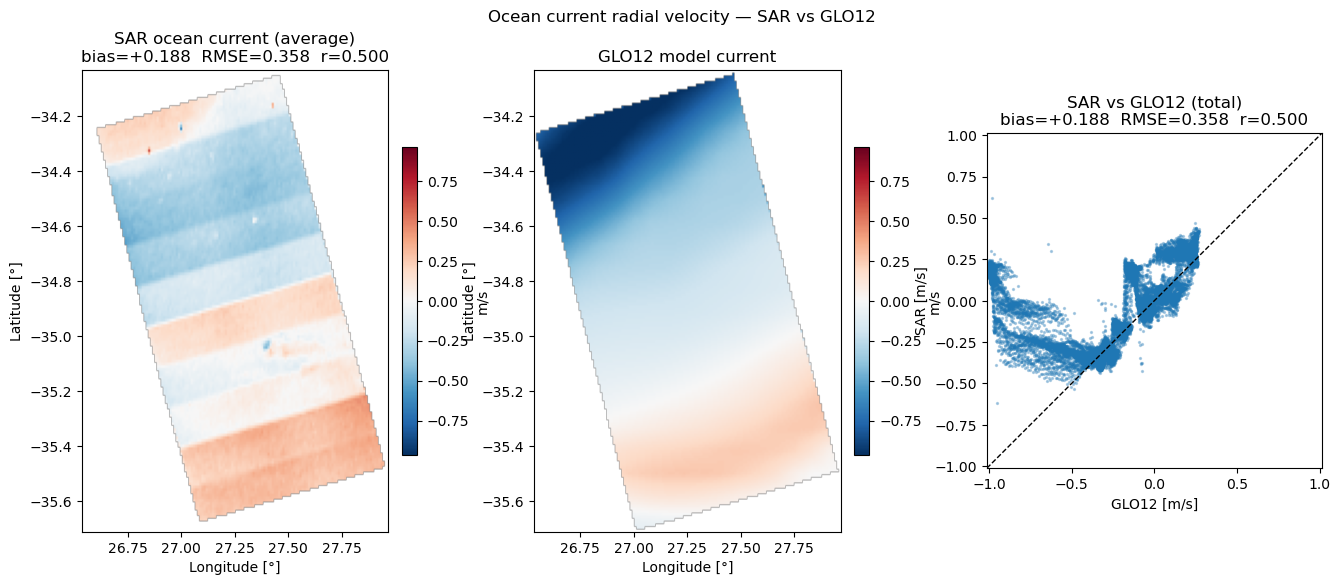


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
     0     +0.1690      0.1814  0.4309
     1     +0.0762      0.0997  -0.0701
     2     -0.0453      0.0788  0.1393
     3     +0.0169      0.0760  0.1225
     4     +0.3145      0.3182  -0.3459
     5     +0.0292      0.0562  -0.3320
     6     -0.0247      0.0662  -0.1412
     7     +0.0562      0.1291  0.1867
     8     +0.3972      0.4554  -0.5608
     9     +0.9534      0.9776  -0.7161
────────────────────────────────────────
 total     +0.1882      0.3579  0.4999


In [8]:
plot_comparison(results, overlap='average')

In [4]:
import sys; sys.path.insert(0, '.')
from scripts.s1_io import find_safe_files, parse_annotation
from scripts.s1_aux import apply_poeorb

files  = find_safe_files(SLC_SAFE, 'iw1', 'vv')
annot  = parse_annotation(files['annotation'])

lpb = annot.lines_per_burst
print(f'linesPerBurst = {lpb}')
print(f'samplesPerBurst = {annot.samples_per_burst}')
print()
for b in annot.bursts:
    expected_row = b.idx * lpb
    # byte_offset / (2 bytes/component * 2 components * samples_per_burst)
    tiff_row = b.byte_offset // (4 * annot.samples_per_burst)
    print(f'Burst {b.idx:2d}: byte_offset={b.byte_offset:>12d}  '
        f'implied_row={tiff_row:>6d}  expected_row={expected_row:>6d}  '
        f'diff={tiff_row - expected_row:>4d}')

linesPerBurst = 1494
samplesPerBurst = 21464

Burst  0: byte_offset=      119835  implied_row=     1  expected_row=     0  diff=   1
Burst  1: byte_offset=   128388699  implied_row=  1495  expected_row=  1494  diff=   1
Burst  2: byte_offset=   256657563  implied_row=  2989  expected_row=  2988  diff=   1
Burst  3: byte_offset=   384926427  implied_row=  4483  expected_row=  4482  diff=   1
Burst  4: byte_offset=   513195291  implied_row=  5977  expected_row=  5976  diff=   1
Burst  5: byte_offset=   641464155  implied_row=  7471  expected_row=  7470  diff=   1
Burst  6: byte_offset=   769733019  implied_row=  8965  expected_row=  8964  diff=   1
Burst  7: byte_offset=   898001883  implied_row= 10459  expected_row= 10458  diff=   1
Burst  8: byte_offset=  1026270747  implied_row= 11953  expected_row= 11952  diff=   1
Burst  9: byte_offset=  1154539611  implied_row= 13447  expected_row= 13446  diff=   1


In [8]:
ds = compute_rvl(SLC_SAFE, 'iw1', 'vv', do_descallop=False)

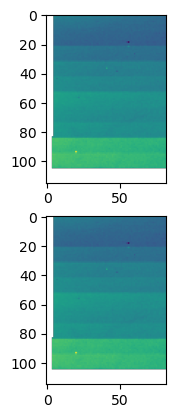

In [9]:
fig, ax = plt.subplots(2,1)
ax[0].imshow(ds["f_dc"])
ax[1].imshow(ds["p1_angle"])

In [8]:
ocn_prod = xr.open_dataset('../data/sentinel-1/S1A_IW_OCN__2SDV_20260205T165251_20260205T165320_063086_07EAEF_420C.SAFE/measurement/s1a-iw-ocn-vv-20260205t165251-20260205t165322-063086-07EAEF-001.nc')

In [9]:
dc_obs = ocn_prod['rvlDcObs']
dc_geo = ocn_prod['rvlDcGeo']
dc_miss = ocn_prod['rvlDcMiss']

dc_corr = dc_obs-dc_geo-dc_miss

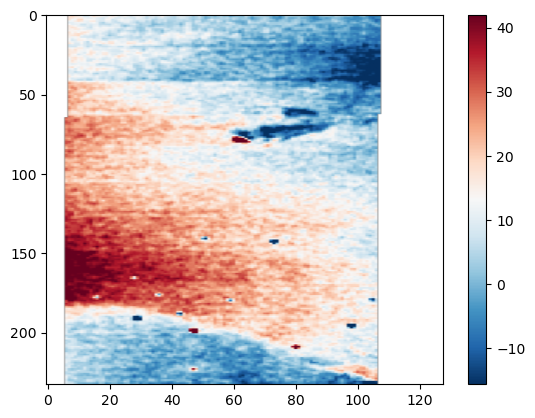

In [13]:
plt.close()
plt.imshow(dc_obs.values[...,0], vmin=np.nanquantile(dc_obs.values[...,0], 0.01), vmax=np.nanquantile(dc_obs.values[...,0], 0.99), aspect='auto', cmap='RdBu_r')
plt.colorbar()
plt.show()